Complete the exercises below For **Assignment #5**.

In this exercise, we are building a logistic regression classification model. We'll work with the [Pima Indians Diabetes Database](https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database).  

Load the `tidymodels` library. 

In [1]:
library('tidymodels')

── Attaching packages ────────────────────────────────────────────────────────────────────────────── tidymodels 1.4.1 ──

✔ broom        1.0.9     ✔ recipes      1.3.1
✔ dials        1.4.2     ✔ rsample      1.3.1
✔ dplyr        1.1.4     ✔ tailor       0.1.0
✔ ggplot2      3.5.2     ✔ tidyr        1.3.1
✔ infer        1.0.9     ✔ tune         2.0.0
✔ modeldata    1.5.1     ✔ workflows    1.3.0
✔ parsnip      1.3.3     ✔ workflowsets 1.1.1
✔ purrr        1.1.0     ✔ yardstick    1.3.2

── Conflicts ───────────────────────────────────────────────────────────────────────────────── tidymodels_conflicts() ──
✖ purrr::discard() masks scales::discard()
✖ dplyr::filter()  masks stats::filter()
✖ dplyr::lag()     masks stats::lag()
✖ recipes::step()  masks stats::step()



The data is located in your homework directory in the `diabetes.csv` file. Read in the data by running the following cell. We are "splitting" the data into training and testing sets. We will evaluate our model's performance with the test set.

In [2]:
diabetes = read.csv("./diabetes.csv") |> mutate(Outcome = factor(Outcome))

split = initial_split(diabetes, strata = Outcome)

diabetes_train = training(split)
diabetes_test = testing(split)

# diabetes_train |> glimpse()
# print(strrep("=", 100))
diabetes_test |> glimpse()

Rows: 192
Columns: 9
$ Pregnancies              <int> 1, 0, 3, 1, 7, 1, 13, 5, 3, 6, 4, 9, 7, 1, 7,…
$ Glucose                  <int> 89, 137, 78, 189, 196, 97, 145, 117, 88, 92, …
$ BloodPressure            <int> 66, 40, 50, 60, 90, 66, 82, 92, 58, 92, 60, 7…
$ SkinThickness            <int> 23, 35, 32, 23, 0, 15, 19, 0, 11, 0, 33, 37, …
$ Insulin                  <int> 94, 168, 88, 846, 0, 140, 110, 0, 54, 0, 192,…
$ BMI                      <dbl> 28.1, 43.1, 31.0, 30.1, 39.8, 23.2, 22.2, 34.…
$ DiabetesPedigreeFunction <dbl> 0.167, 2.288, 0.248, 0.398, 0.451, 0.487, 0.2…
$ Age                      <int> 21, 33, 26, 59, 41, 22, 57, 38, 22, 28, 33, 4…
$ Outcome                  <fct> 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, …


Glimpse the `diabetes_train` table.

In [3]:
diabetes_train |> glimpse()

Rows: 576
Columns: 9
$ Pregnancies              <int> 1, 5, 10, 4, 10, 1, 3, 8, 5, 10, 11, 3, 7, 7,…
$ Glucose                  <int> 85, 116, 115, 110, 139, 103, 126, 99, 109, 12…
$ BloodPressure            <int> 66, 74, 0, 92, 80, 30, 88, 84, 75, 78, 76, 64…
$ SkinThickness            <int> 29, 0, 0, 0, 0, 38, 41, 0, 26, 31, 0, 25, 18,…
$ Insulin                  <int> 0, 0, 0, 0, 0, 83, 235, 0, 0, 0, 0, 70, 0, 0,…
$ BMI                      <dbl> 26.6, 25.6, 35.3, 37.6, 27.1, 43.3, 39.3, 35.…
$ DiabetesPedigreeFunction <dbl> 0.351, 0.201, 0.134, 0.191, 1.441, 0.183, 0.7…
$ Age                      <int> 31, 30, 29, 30, 57, 33, 27, 50, 60, 45, 35, 2…
$ Outcome                  <fct> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …


❓ Which variable is suitable as the "outcome" in a logistic regression model?

**Answer:**

If I'm understanding the documentation for the dataset correctly it seems like there are 8 columns medical predictors of whether or not an individual has diabetes. Whether or not the person has diabetes is captured in the ```Outcome``` field. Given that logistic regression can be used to determine the liklihood of a binary outcome I think using the ```Outcome``` column from the data as the outcome of the model seems reasonable.

❓ Navigate to [Kaggle page](https://www.kaggle.com/datasets/mathchi/diabetes-data-set) for this dataset. Find descriptions for the `Glucose` and `BMI` columns. Add these descriptions to the [Markdown table](https://www.markdownguide.org/extended-syntax/#tables) below.

| Column name | Description |
| :---------- | :---------- |
| Glucose     | Plasma glucose concentration a 2 hours in an oral glucose tolerance test            |
| BMI         | Body mass index (weight in kg/(height in m)^2)            |

Make a bar chart showing the frequency of each "outcome" in the `Outcome` column from your `diabetes_train` data.

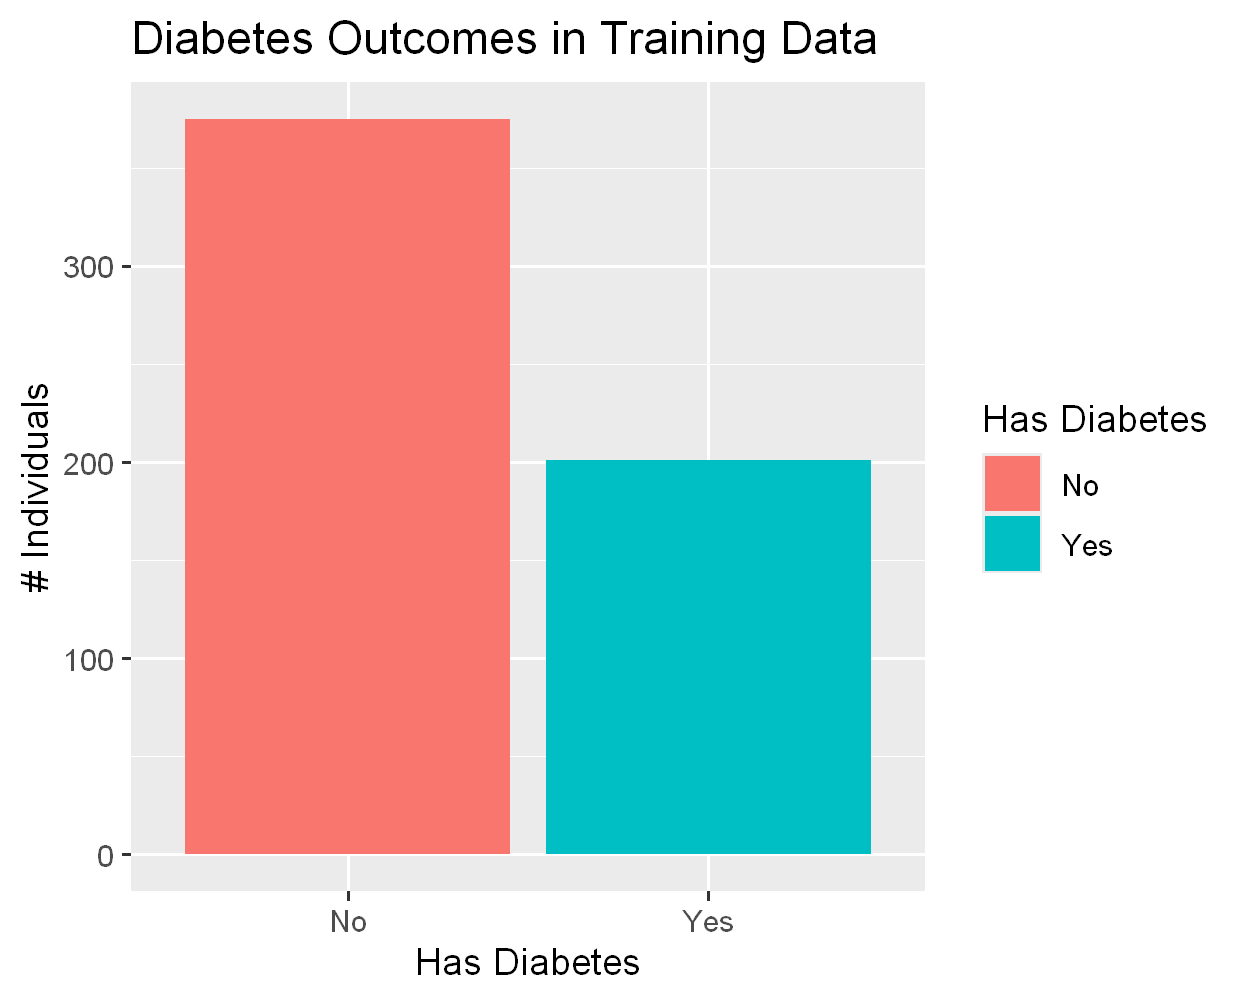

In [4]:
ggplot(diabetes_train, aes(x=Outcome, fill=Outcome)) +
    geom_bar(stat = "count") +
    scale_x_discrete(labels = c("No", "Yes")) +
    scale_fill_discrete(
        name = "Has Diabetes",
        labels = c("No", "Yes")
    ) +
    labs(
        title = "Diabetes Outcomes in Training Data",
        x = "Has Diabetes",
        y = "# Individuals"
    )

In [5]:
table(diabetes_train$Outcome)


  0   1 
375 201 

❓ Is the data balanced? I.e. do we have equal counts of each outcome?

**Answer:**

The training data is not balanced as the split is 375 individuals without diabetes (65%) vs 201 individuals with diabetes (35%). The fact that this question was asked made me search as to why this was an issue and I found this interesting article: [balanced logistic regression improving minority class detection with class weights](https://codesignal.com/learn/courses/evaluation-metrics-advanced-techniques/lessons/balanced-logistic-regression-improving-minority-class-detection-with-class-weights)



Run the code below to create a table for plotting the predictors we will use in our model: `Glucose` and `BMI`. 

In [6]:
plot_df = diabetes_train |>
    select(Outcome, Glucose, BMI)

plot_df |> head()

,Outcome,Glucose,BMI
,<fct>,<int>,<dbl>
1,0,85,26.6
2,0,116,25.6
3,0,115,35.3
4,0,110,37.6
5,0,139,27.1
6,0,103,43.3


In [7]:
plot_df = diabetes_train |>
    select(Outcome, Glucose, BMI) |>
    pivot_longer(cols = c(Glucose, BMI))

plot_df |> head()

Outcome,name,value
<fct>,<chr>,<dbl>
0,Glucose,85.0
0,BMI,26.6
0,Glucose,116.0
0,BMI,25.6
0,Glucose,115.0
0,BMI,35.3


Using `plot_df`, make a chart showing the relationship of `Glucose` and `BMI` with `Outcome`. 

- use `geom_jitter` for your "geom"
- `facet_wrap` your chart by the `name` variable. (e.g. `facet_wrap(~name, ncol = 2, scales = 'free_x')`)

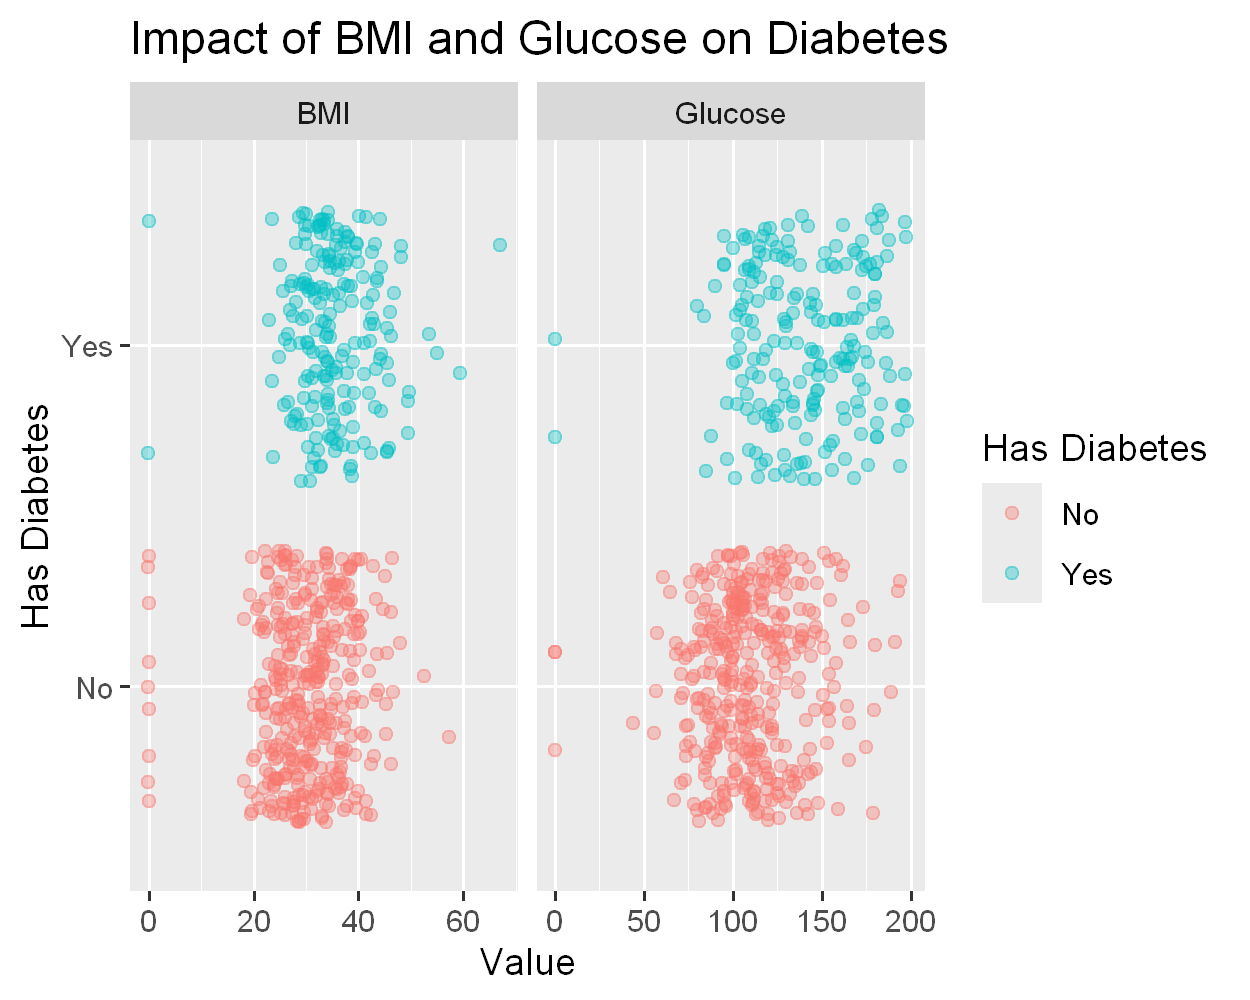

In [8]:
ggplot(plot_df, aes(x = value, y = Outcome, color = Outcome)) +
    geom_jitter(width = 0.2, alpha = 0.35) +
    facet_wrap(~name, ncol = 2, scales = "free_x") +
    scale_y_discrete(labels = c("No", "Yes")) +
    scale_color_discrete(
        name = "Has Diabetes",
        labels = c("No", "Yes")
    ) +
    labs(
        title = "Impact of BMI and Glucose on Diabetes",
        y = "Has Diabetes",
        x = "Value"
    )

❓ What happens when you remove the `scales = 'free_x'` argument from the `facet_wrap` function?

**Answer:**

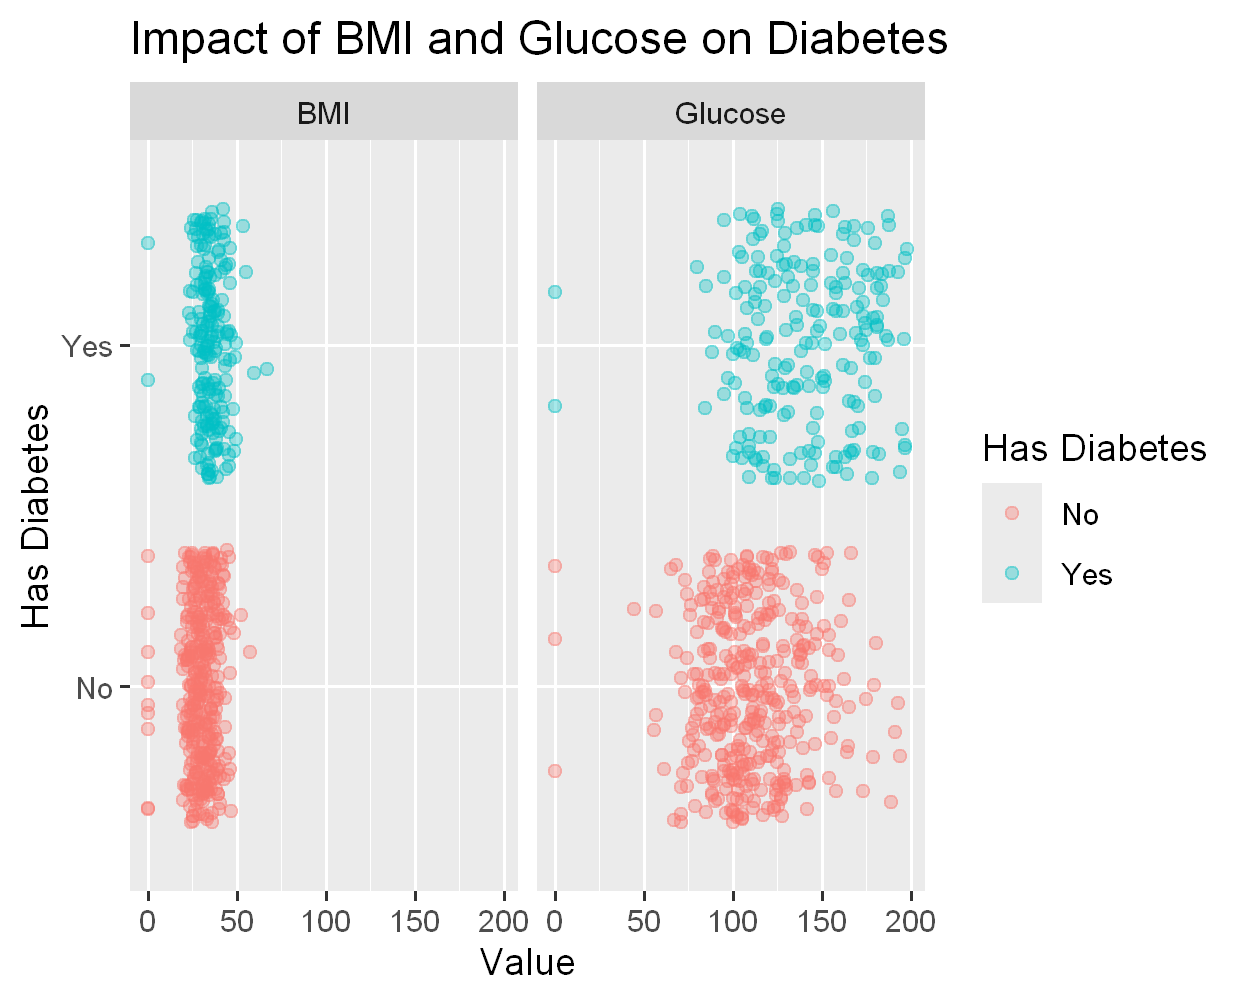

In [9]:
ggplot(plot_df, aes(x = value, y = Outcome, color = Outcome)) +
    geom_jitter(width = 0.2, alpha = 0.35) +
    facet_wrap(~name, ncol = 2) +
    scale_y_discrete(labels = c("No", "Yes")) +
    scale_color_discrete(
        name = "Has Diabetes",
        labels = c("No", "Yes")
    ) +
    labs(
        title = "Impact of BMI and Glucose on Diabetes",
        y = "Has Diabetes",
        x = "Value"
    )

If you drop ```scales = 'free_x'``` from ```facet_wrap``` then both of the subplots are locked to the same range along the x-axis. This is especially negative for the ```BMI``` plot becuase the range is ballooned from ~0-70 to ~0-210. The ```Glucose``` plot is not impacted.

Using your training data, build logistic regression model of `Outcome` with `BMI` and `Glucose` as predictors. 
- Use "glm" for you engine
- The formula for your fit function will be `Outcome ~ BMI + Glucose`

In [10]:
mod = logistic_reg() |> set_engine('glm')
mod

Logistic Regression Model Specification (classification)

Computational engine: glm 


In [16]:
mod_fit = mod |> fit(Outcome ~ BMI + Glucose, diabetes_train) 
mod_fit

parsnip model object


Call:  stats::glm(formula = Outcome ~ BMI + Glucose, family = stats::binomial, 
    data = data)

Coefficients:
(Intercept)          BMI      Glucose  
   -7.05978      0.07417      0.03210  

Degrees of Freedom: 575 Total (i.e. Null);  573 Residual
Null Deviance:	    745.1 
Residual Deviance: 593.7 	AIC: 599.7

Using `augment` with your fitted model and the `diabetes_test` data as arguments, create a new dataset called `diabetes_test_wPred` that is the `diabetes_test` table including predictions from your model. 

In [17]:
diabetes_test_wPred = augment(mod_fit, diabetes_test)

diabetes_test_wPred |> glimpse()

Rows: 192
Columns: 12
$ .pred_class              <fct> 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, …
$ .pred_0                  <dbl> 0.8926772, 0.3693191, 0.9052054, 0.2243660, 0…
$ .pred_1                  <dbl> 0.10732281, 0.63068093, 0.09479463, 0.7756340…
$ Pregnancies              <int> 1, 0, 3, 1, 7, 1, 13, 5, 3, 6, 4, 9, 7, 1, 7,…
$ Glucose                  <int> 89, 137, 78, 189, 196, 97, 145, 117, 88, 92, …
$ BloodPressure            <int> 66, 40, 50, 60, 90, 66, 82, 92, 58, 92, 60, 7…
$ SkinThickness            <int> 23, 35, 32, 23, 0, 15, 19, 0, 11, 0, 33, 37, …
$ Insulin                  <int> 94, 168, 88, 846, 0, 140, 110, 0, 54, 0, 192,…
$ BMI                      <dbl> 28.1, 43.1, 31.0, 30.1, 39.8, 23.2, 22.2, 34.…
$ DiabetesPedigreeFunction <dbl> 0.167, 2.288, 0.248, 0.398, 0.451, 0.487, 0.2…
$ Age                      <int> 21, 33, 26, 59, 41, 22, 57, 38, 22, 28, 33, 4…
$ Outcome                  <fct> 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, …


Run the code below to generate a confusion matrix for your model predictions. 

(❗️Hint: See Table 4.4 from [*Introduction to Statistical Learning (Version 2)*](https://www.statlearning.com/) for an example confusion matrix.)

In [18]:
diabetes_test_wPred = augment(mod_fit, new_data = diabetes_test)

diabetes_test_wPred |> conf_mat(Outcome, .pred_class)

          Truth
Prediction   0   1
         0 116  31
         1   9  36

❓ Based on the confusion matrix above, 
- How many individuals had diabetes in your test data?
- Of those that actually had diabetes, how many were predicted to have diabetes by your model?
- How many individuals predicted to have diabetes did not have diabetes?

**Answer:**

Based on the confusion matrix 67 individuals had diabetes (31 + 36, the right column). My model predicted that 36 of those 67 individuals had diabetes. My model predicted that 9 people had diabetes that, in reality, did not have diabetes.